# **Basic Stats** - data analysis

In [20]:
# ==== IMPORSTS & PACKAGES ====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from scipy.stats import norm

# ==== IMPORT FILES ====
IMPORT_PATH = "../data/data_analysis_files/"
FILE_FILTERED_GRADES = "df_filtered_final_86pct_grades_09042026.parquet"

# ==== EXPORT SETTINGS ====
# Export images to folder
IMG_EXPORT = True 
IMG_EXPORT_PATH = "exported_plots/basic_stats/"

EXPORT = True
EXPORT_PATH = None #TBD

In [21]:
# ==== FUNCTIONS ====
def load_parquet_to_df(parquet_path, na=False):
    try:
        df = pd.read_parquet(parquet_path)
        print(f"Successfully loaded Parquet from {parquet_path}")
        print(f"DataFrame shape: {df.shape}")
        if na:
            print(f"DataFrame N/A counts:\n{df.isna().sum()}\n")
        print(f"DataFrame columns: {df.columns.tolist()}\n")
        return df
    except Exception as e:
        print(f"Error loading Parquet from {parquet_path}: {e}")
        return None

# ==== LOAD DATAFRAME ====
df_filtered_final = load_parquet_to_df(IMPORT_PATH + FILE_FILTERED_GRADES)

Successfully loaded Parquet from ../data/data_analysis_files/df_filtered_final_86pct_grades_09042026.parquet
DataFrame shape: (6254, 47)
DataFrame columns: ['Timestamp', 'Author', 'ID', 'Publication Year', 'member_id_ss', 'primary_member_id_s', 'Title', 'MASTER THESIS TITLE', 'BY', 'SUPERVISED BY', 'pdf_file', 'num_tot_pages', 'num_cont_pages', 'num_words_full', 'num_words_cont', 'handin_month', 'num_figures', 'num_tables', 'num_references', 'equation_count', 'pdf_sha256', 'total_sentences', 'total_words', 'unique_words', 'avg_sentence_length', 'avg_word_length', 'lexical_diversity', 'Department_new', 'grading_scientific_contribution', 'grading_methodological_rigor', 'grading_technical_implementation', 'grading_literature_review', 'grading_process_professionalism', 'grading_impact_applicability', 'grading_research_question_alignment', 'grading_total_score', 'grading_meta_attempts', 'grading_meta_original_chars', 'grading_meta_trimmed_at_references', 'grading_meta_input_chars', 'grading

## Excluding rows with no grading

In [40]:
# remove rows with NaN and 0 in grading_total_score
df_filtered_final_noNA = df_filtered_final[(df_filtered_final["grading_total_score"].notnull()) & (df_filtered_final["grading_total_score"] != 0)]

print(f"DataFrame shape is: {df_filtered_final.shape}")
print(f"DataFrame shape after dropping NaN and 0 in grading_total_score: {df_filtered_final_noNA.shape}")

DataFrame shape is: (6254, 47)
DataFrame shape after dropping NaN and 0 in grading_total_score: (5366, 47)


# General stats

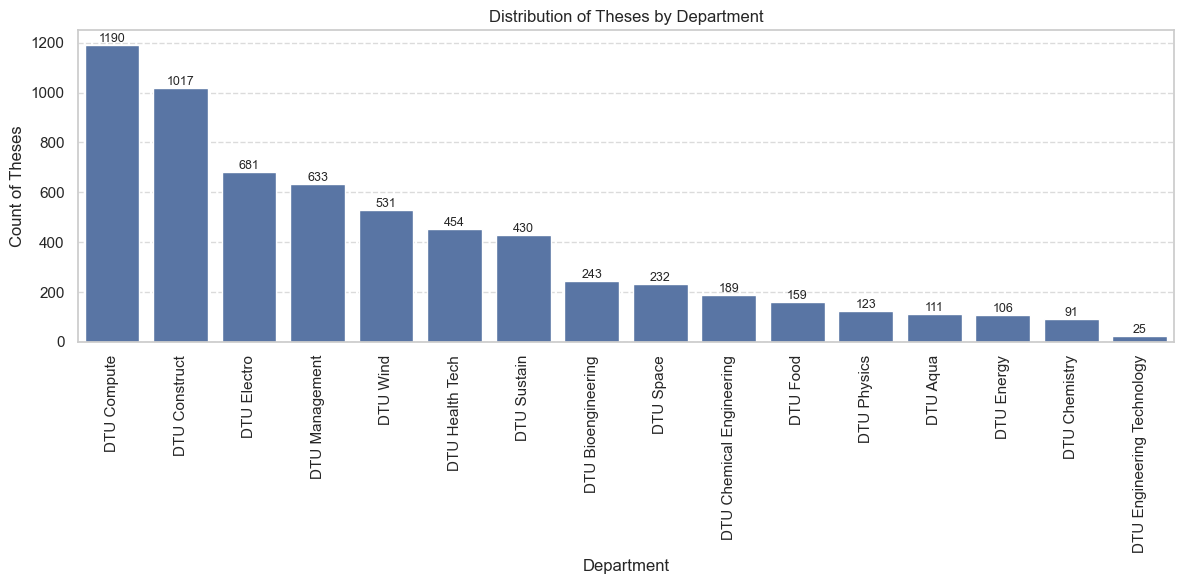

In [41]:
# print table of df department_new count of each unique
dept_counts = df_filtered_final['Department_new'].value_counts()
#print("--- Thesis Count by Department ---")
#print(dept_counts)

# plot df department_new count of each unique + show count on bars
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df_filtered_final,
    x='Department_new',
    order=df_filtered_final['Department_new'].value_counts().index
)

# add count labels at the end (top) of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=0, fontsize=9)

plt.xticks(rotation=90)
plt.title('Distribution of Theses by Department')
plt.xlabel('Department')
plt.ylabel('Count of Theses')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'department_distribution.png')
plt.show()

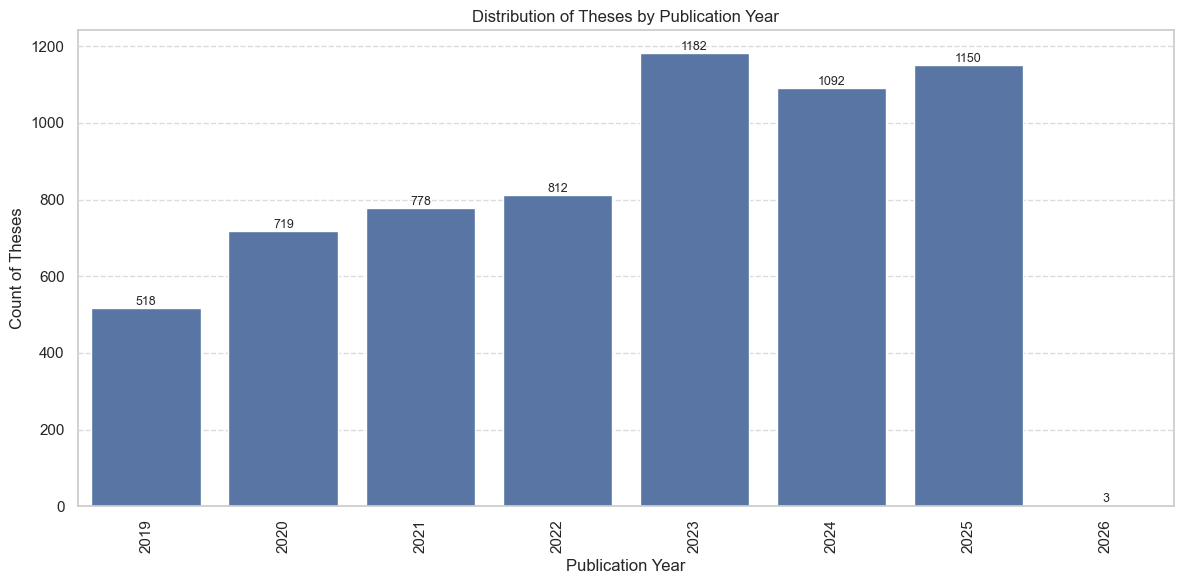

In [48]:
# plot df "Publication Year" count of each unique + show count on bars
plt.figure(figsize=(12, 6))

year_order = sorted(pd.to_numeric(df_filtered_final["Publication Year"], errors="coerce").dropna().unique())

ax = sns.countplot(
    data=df_filtered_final,
    x='Publication Year',
    order=year_order
)

# add count labels at the end (top) of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=0, fontsize=9)

plt.xticks(rotation=90)
plt.title('Distribution of Theses by Publication Year')
plt.xlabel('Publication Year')
plt.ylabel('Count of Theses')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'publication_year_distribution.png')
plt.show()

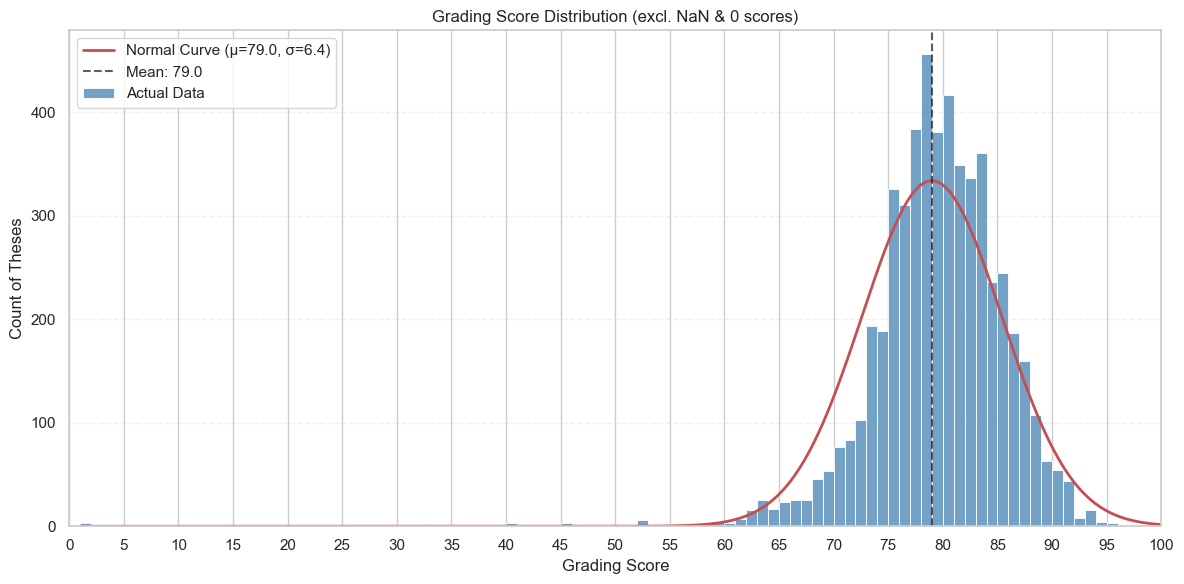

In [43]:
show_count = False

# 1. Prepare data
scores = pd.to_numeric(df_filtered_final_noNA["grading_total_score"], errors="coerce").dropna()

# 2. Calculate parameters
mu, std = scores.mean(), scores.std()

# 3. Plotting
plt.figure(figsize=(12, 6))

# Histogram - Ensuring bins cover the 1-100 range precisely
bin_range = np.arange(1, 102) 
ax = sns.histplot(scores, bins=bin_range, color="steelblue", kde=False, label="Actual Data")

# 4. Overlay the Normal Distribution (Red Line)
# Even if the data is skewed, this shows HOW much it deviates from a "perfect" bell curve
x = np.linspace(1, 100, 1000)
# Scale the PDF: (PDF value) * (Total Number of Samples) * (Bin Width)
p = norm.pdf(x, mu, std) * len(scores) * 1 

plt.plot(x, p, 'r', linewidth=2, label=f'Normal Curve (μ={mu:.1f}, σ={std:.1f})')

# 5. Add a vertical line for the Mean to visualize the skew
plt.axvline(mu, color='k', linestyle='--', alpha=0.7, label=f'Mean: {mu:.1f}')

if show_count == True:
    # Label bars (optional: might get crowded if 100 bars are all filled)
    for container in ax.containers:
        # Only label bars with a count > 0 to keep it clean
        ax.bar_label(container, fmt='%d', padding=2, fontsize=8)

# Formatting
plt.xlim(1, 100)
plt.xticks(np.arange(0, 101, 5))
plt.title("Grading Score Distribution (excl. NaN & 0 scores)")
plt.xlabel("Grading Score")
plt.ylabel("Count of Theses")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'grading_score_distribution.png')
plt.show()

In [44]:
#show 10% lowest total scores, show collumns: "title", "Department_new", "Publication Year", "grading_total_score"
df_filtered_final_noNA.nsmallest(int(0.1 * len(df_filtered_final_noNA)), "grading_total_score")[["pdf_file", "Department_new", "Publication Year", "grading_total_score"]]

,pdf_file,Department_new,Publication Year,grading_total_score
1199,612e0e46d9001d0172372029_Autonomous indoor exp...,DTU Electro,2021,1.0
2238,62d0b03e695d6726170247b6_Evaluating the qualit...,DTU Sustain,2022,1.0
2935,62d0b03e695d6726170247b6_Evaluating the qualit...,DTU Sustain,2022,1.0
1193,669468d1cfd87be8f3dfe478_Ø-modeller til estima...,DTU Compute,2024,2.0
2874,64f12babfdcf8022a630b09a_Fuzzing Smart Contrac...,DTU Compute,2023,8.0
...,...,...,...,...
5982,62f98ebe49a04803a4a5a732_Distributed Remote At...,DTU Compute,2022,72.0
5983,62f98eb543534303a4a6fbcf_Designing nonlinear m...,DTU Electro,2022,72.0
5984,64f5203ff0fb4122d1c8cda5_Development of syngas...,DTU Chemical Engineering,2023,72.0
5993,62162426e8b236235e76241d_Tenant control plane ...,DTU Electro,2022,72.0


# DEVELOPMENT

## First "analysis"

In [ ]:
# 1. Load the data
# Choosing the file where NaN and 0 values in grading_total_score have been removed for accurate analysis
df = df_filtered_final_noNA.copy()

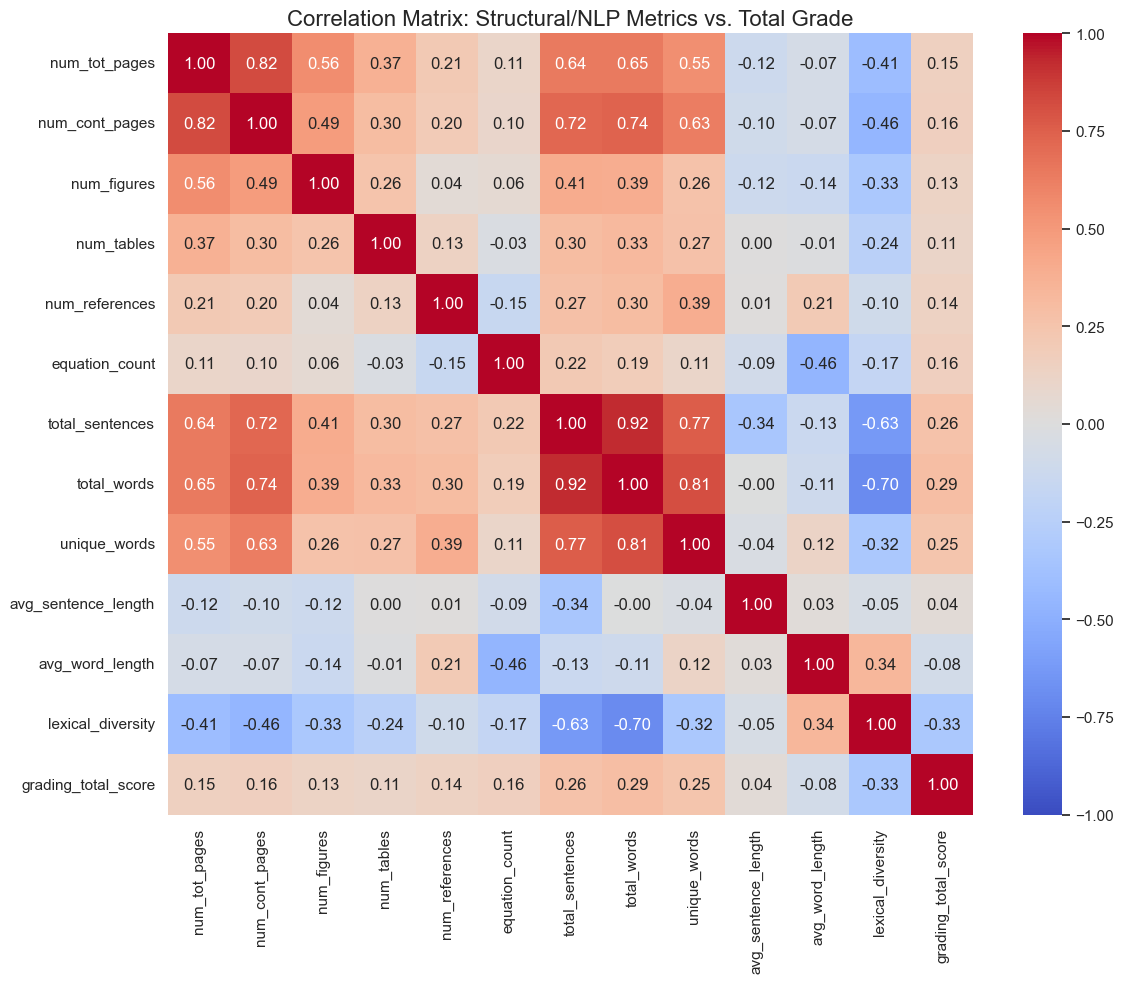

/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_54275/3122261958.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department_new', y=target, order=order, palette='viridis')


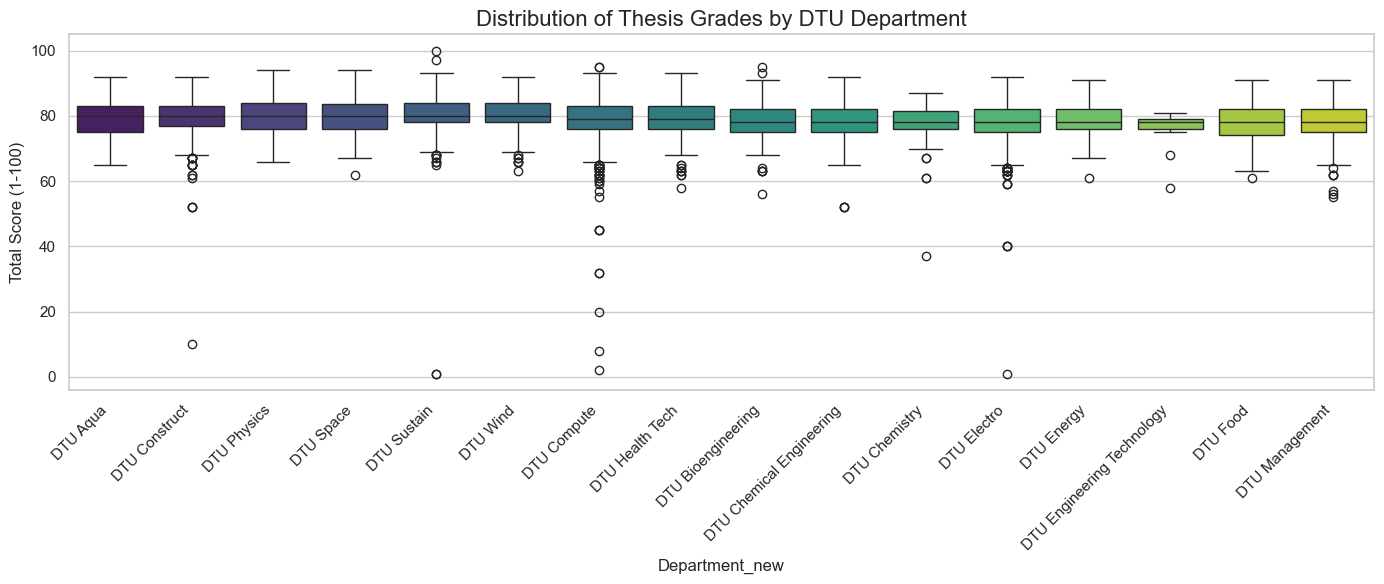

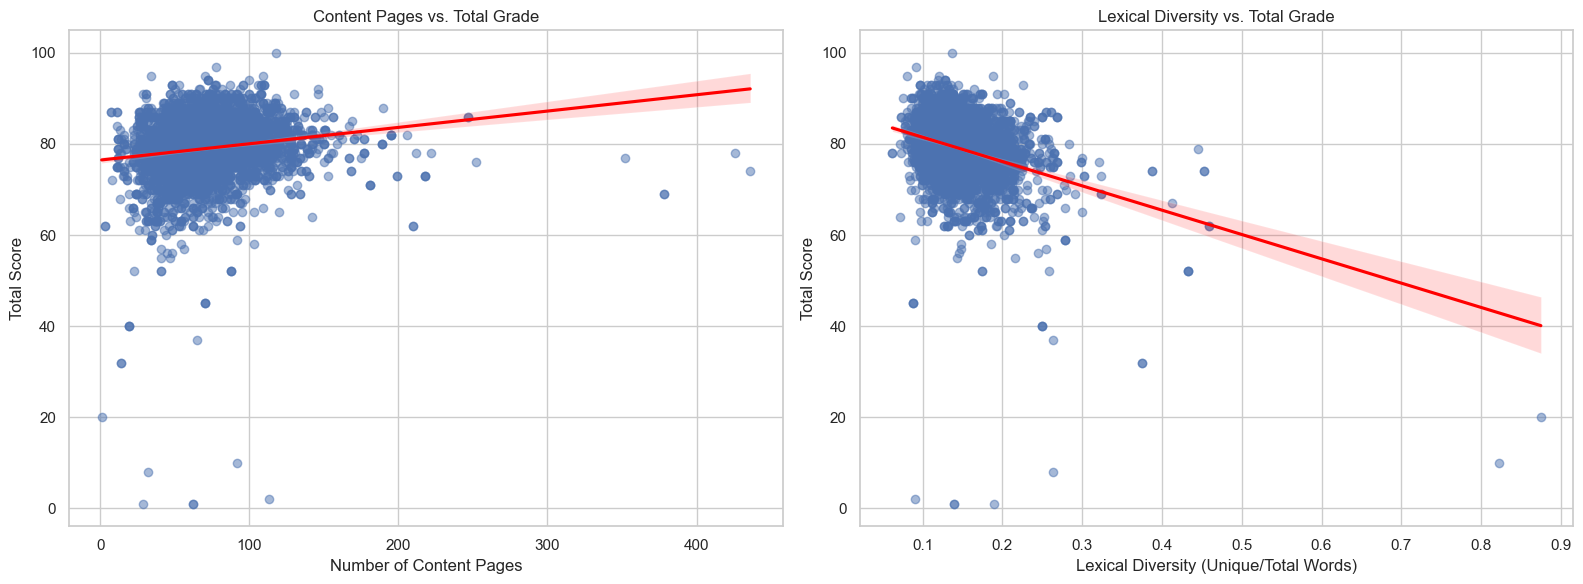

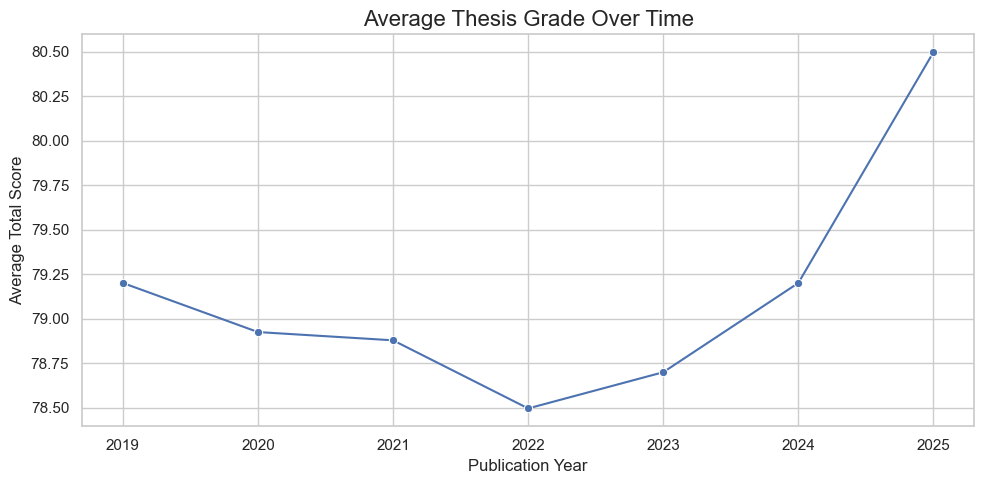

In [ ]:
# 2. Clean the handin_month column (as you noted: disregard the year)
# Assuming the format is something like "May-2023" or "2023-05", we extract just the month text or number.
# If it's a string like "May 2023", we can do:
df['handin_month_clean'] = df['handin_month'].astype(str).str.replace(r'\d+', '', regex=True).str.strip()

# 3. Define the feature categories
nlp_structural_features = [
    'num_tot_pages', 'num_cont_pages', 'num_figures', 'num_tables', 
    'num_references', 'equation_count', 'total_sentences', 'total_words', 
    'unique_words', 'avg_sentence_length', 'avg_word_length', 'lexical_diversity'
]

sub_grades = [
    'grading_scientific_contribution', 'grading_methodological_rigor',
    'grading_technical_implementation', 'grading_literature_review',
    'grading_process_professionalism', 'grading_impact_applicability',
    'grading_research_question_alignment'
]

target = 'grading_total_score'

# Set visual style
sns.set_theme(style="whitegrid")

# ==========================================
# PLOT 1: Correlation Heatmap (NLP & Structural)
# ==========================================
plt.figure(figsize=(12, 10))
corr_matrix = df[nlp_structural_features + [target]].corr()

# Highlight correlations with the total score
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix: Structural/NLP Metrics vs. Total Grade', fontsize=16)
plt.tight_layout()
#plt.savefig('correlation_heatmap.png')
plt.show()

# ==========================================
# PLOT 2: Department Comparisons
# ==========================================
plt.figure(figsize=(14, 6))
# Sort departments by median score for better readability
order = df.groupby('Department_new')[target].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Department_new', y=target, order=order, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Thesis Grades by DTU Department', fontsize=16)
plt.ylabel('Total Score (1-100)')
plt.tight_layout()
#plt.savefig('department_boxplot.png')
plt.show()

# ==========================================
# PLOT 3: The "Sweet Spot" Scatter Plots
# ==========================================
# Let's plot Content Pages and Lexical Diversity against the Total Score
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df, x='num_cont_pages', y=target, ax=axes[0], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Content Pages vs. Total Grade')
axes[0].set_xlabel('Number of Content Pages')
axes[0].set_ylabel('Total Score')

sns.regplot(data=df, x='lexical_diversity', y=target, ax=axes[1], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1].set_title('Lexical Diversity vs. Total Grade')
axes[1].set_xlabel('Lexical Diversity (Unique/Total Words)')
axes[1].set_ylabel('Total Score')

plt.tight_layout()
#plt.savefig('scatter_trends.png')
plt.show()

# ==========================================
# PLOT 4: Grading Trends Over Time
# ==========================================
plt.figure(figsize=(10, 5))
#sns.lineplot(data=df, x='Publication Year', y=target, marker='o', errorbar=None)
sns.lineplot(data=df.groupby('Publication Year')[target].median().reset_index(), x='Publication Year', y=target, marker='o')
plt.title('Median Thesis Grade Over Time', fontsize=16)
plt.ylabel('Median Total Score')
plt.xticks(df['Publication Year'].dropna().unique()) # Ensure whole years
plt.tight_layout()
#plt.savefig('time_trend.png')
plt.show()

### sub-grades

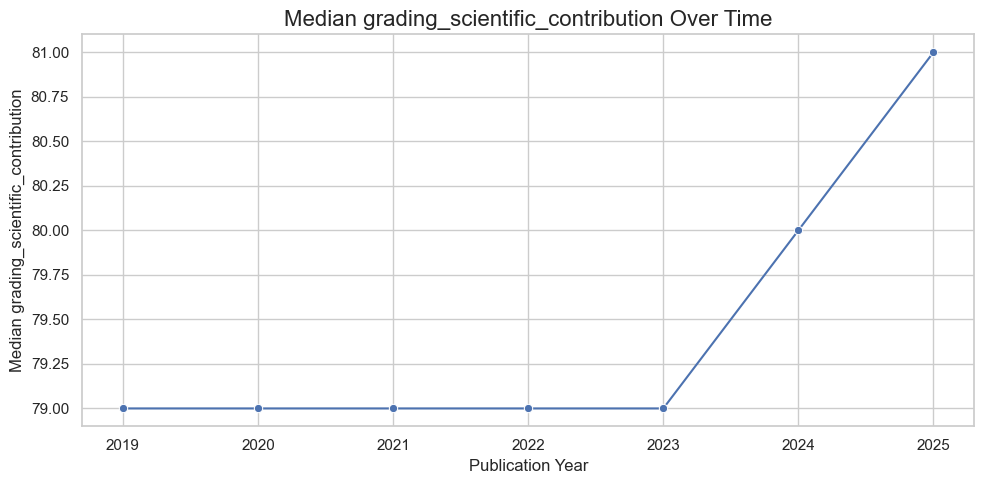

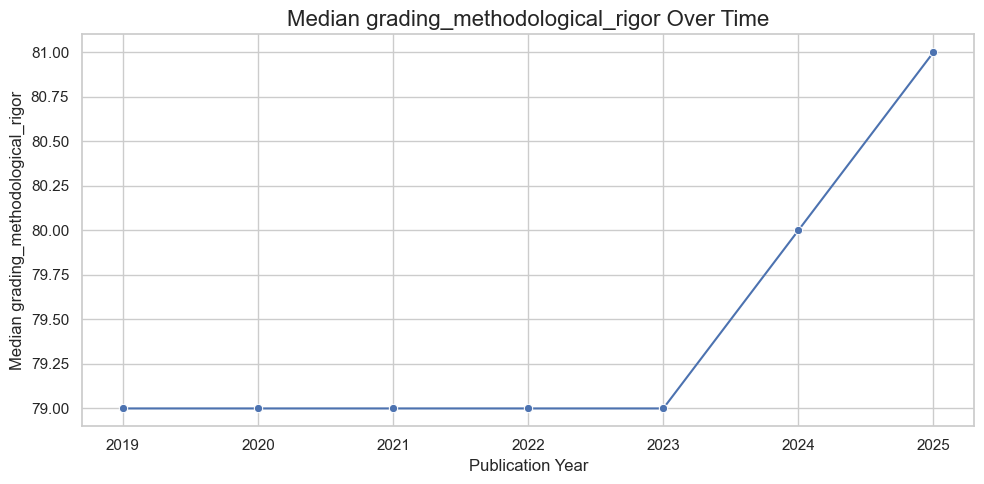

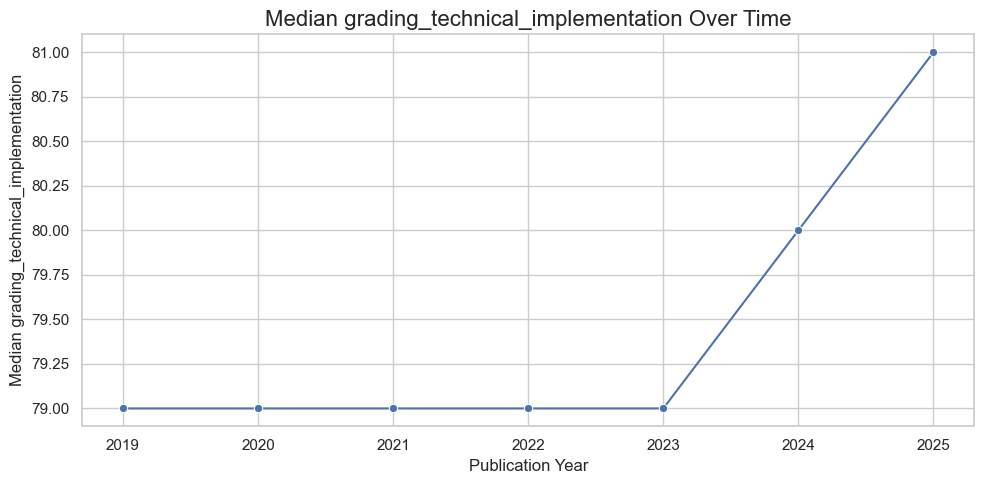

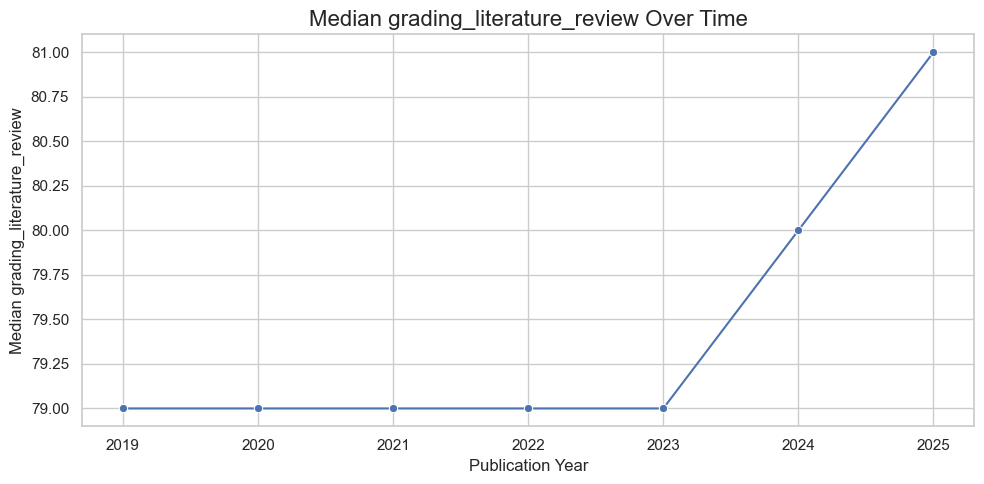

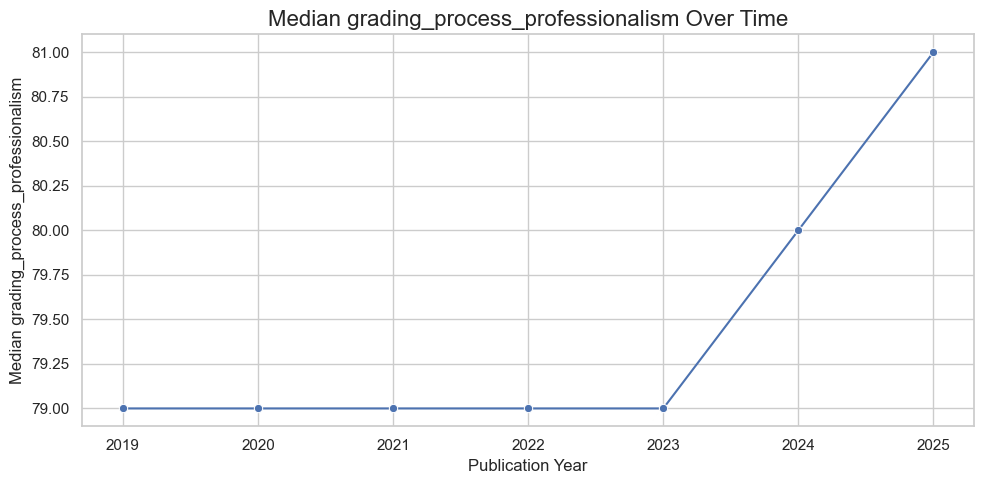

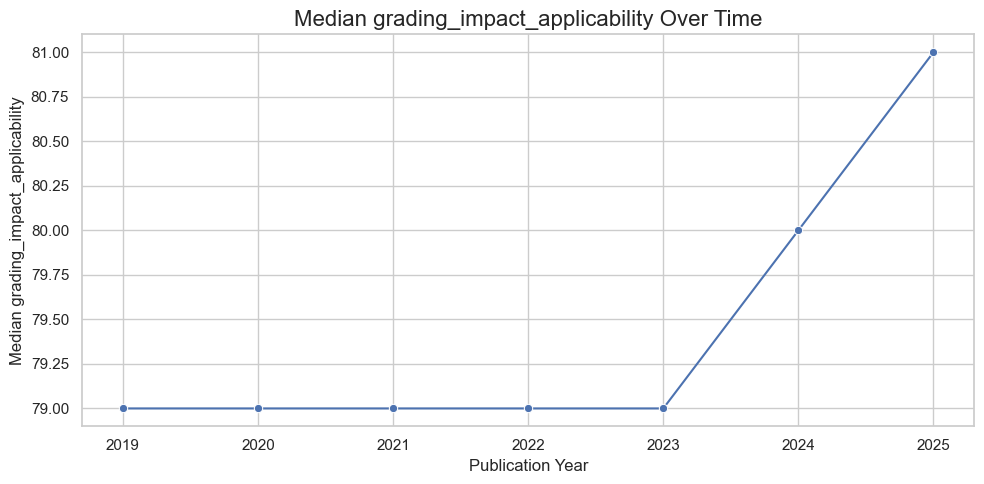

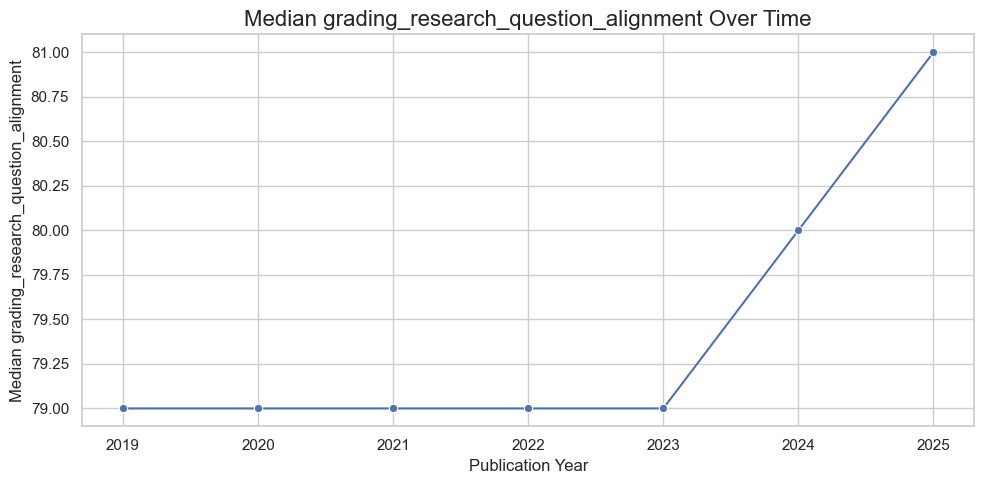

In [55]:
# ==========================================
# PLOT 5: Sub-Grading Trends Over Time
# ==========================================

for i in sub_grades:
    plt.figure(figsize=(10, 5))
    #sns.lineplot(data=df, x='Publication Year', y=i, marker='o', errorbar=None)
    sns.lineplot(data=df.groupby('Publication Year')[target].median().reset_index(), x='Publication Year', y=target, marker='o')
    plt.title(f'Median {i} Over Time', fontsize=16)
    plt.ylabel(f'Median {i}')
    plt.xticks(df['Publication Year'].dropna().unique()) # Ensure whole years
    plt.tight_layout()
    #plt.savefig(f'{i}_time_trend.png')
    plt.show()

## Temporal Analysis

/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_54275/3699785108.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='clean_month_str', palette='crest')


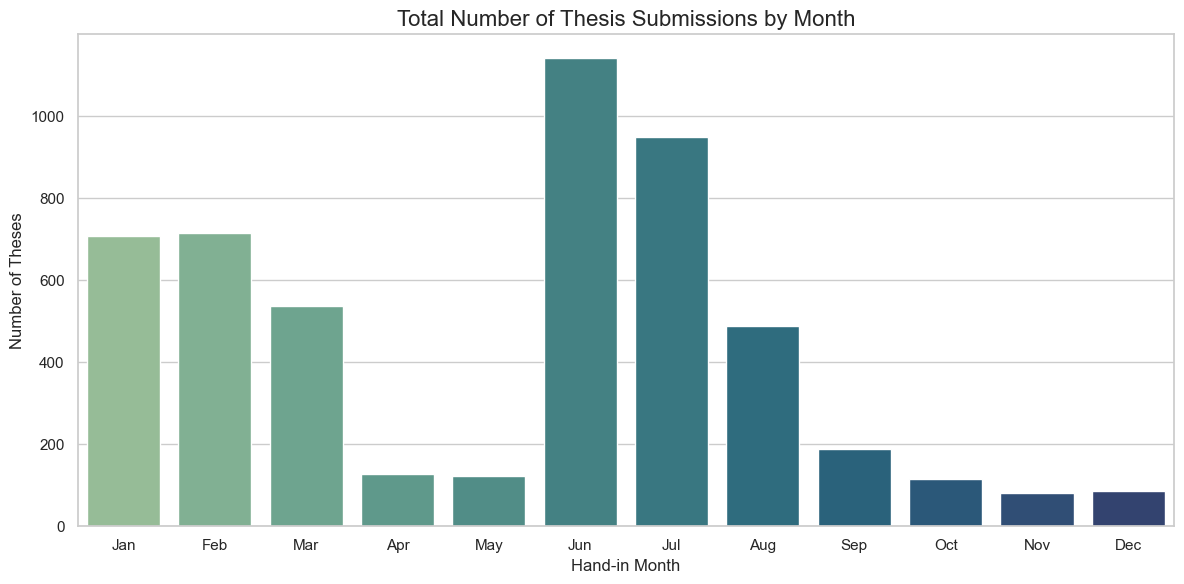

/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_54275/3699785108.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='clean_month_str', y=target, palette='viridis')


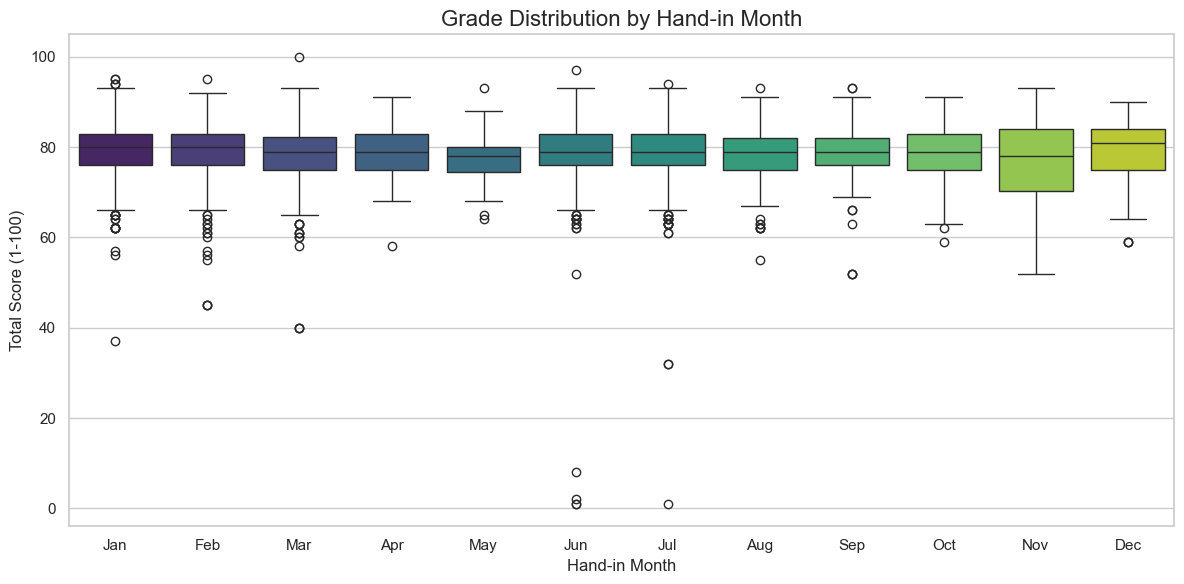

/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_54275/3699785108.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Publication Year', y=target, palette='magma')


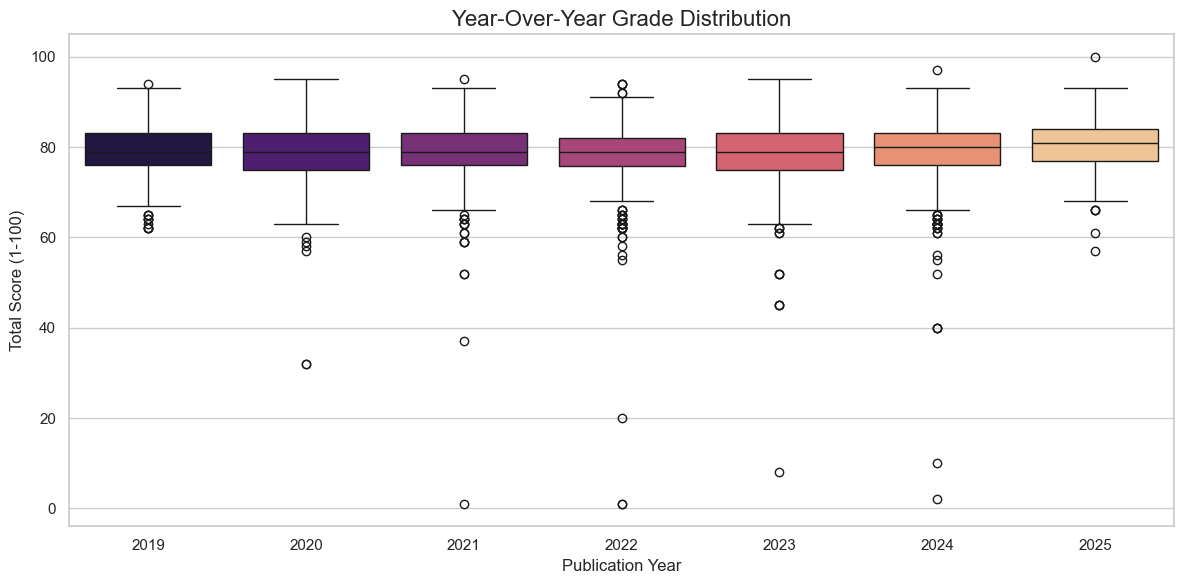

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import calendar

# 1. Load the dataset
target = 'grading_total_score'

# 2. Clean the handin_month column
# This function extracts the month name, ignoring numbers (years) and standardizing the format.
def extract_month(text):
    if pd.isna(text):
        return None
    # Remove numbers and strip whitespace
    clean_text = re.sub(r'\d+', '', str(text)).strip().title()
    # Take the first 3 letters to standardize (e.g., "January", "Jan", "Jan.") -> "Jan"
    return clean_text[:3] if len(clean_text) >= 3 else None

df['clean_month_str'] = df['handin_month'].apply(extract_month)

# Create a mapping to ensure months are plotted in chronological order, not alphabetical
month_abbr = [calendar.month_abbr[i] for i in range(1, 13)] # ['Jan', 'Feb', 'Mar', ...]
df['clean_month_str'] = pd.Categorical(df['clean_month_str'], categories=month_abbr, ordered=True)

# Set the visual style
sns.set_theme(style="whitegrid")

# ==========================================
# PLOT 1: Volume of Theses by Month
# ==========================================
# Question: Are there massive spikes in hand-ins (e.g., June/July)?
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='clean_month_str', palette='crest')
plt.title('Total Number of Thesis Submissions by Month', fontsize=16)
plt.xlabel('Hand-in Month')
plt.ylabel('Number of Theses')
plt.tight_layout()
#plt.savefig('submissions_by_month.png')
plt.show()

# ==========================================
# PLOT 2: Grade Distribution by Month
# ==========================================
# Question: Does handing in during a "rush" month lower the average grade?
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='clean_month_str', y=target, palette='viridis')
plt.title('Grade Distribution by Hand-in Month', fontsize=16)
plt.xlabel('Hand-in Month')
plt.ylabel('Total Score (1-100)')
plt.tight_layout()
#plt.savefig('grades_by_month.png')
plt.show()

# ==========================================
# PLOT 3: Grade Consistency Over the Years
# ==========================================
# Question: Is there grade inflation, or is the scoring consistent year-over-year?
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Publication Year', y=target, palette='magma')
plt.title('Year-Over-Year Grade Distribution', fontsize=16)
plt.xlabel('Publication Year')
plt.ylabel('Total Score (1-100)')
# Ensure years are displayed as integers
years = sorted(df['Publication Year'].dropna().unique())
plt.xticks(ticks=range(len(years)), labels=[int(y) for y in years]) 
plt.tight_layout()
#plt.savefig('grades_by_year.png')
plt.show()

# ARCHIVES

## [new legacy element here]

## [new legacy element here]